Detected Peaks in Windows:
Flare 1 — Time: 2545.3208 | Flux: 1.5216
Flare 2 — Time: 2542.0108 | Flux: 1.1064
Flare 3 — Time: 2543.0164 | Flux: 1.1051
Flare 4 — Time: 2543.2817 | Flux: 1.0716
Flare 5 — Time: 2544.9291 | Flux: 1.0452


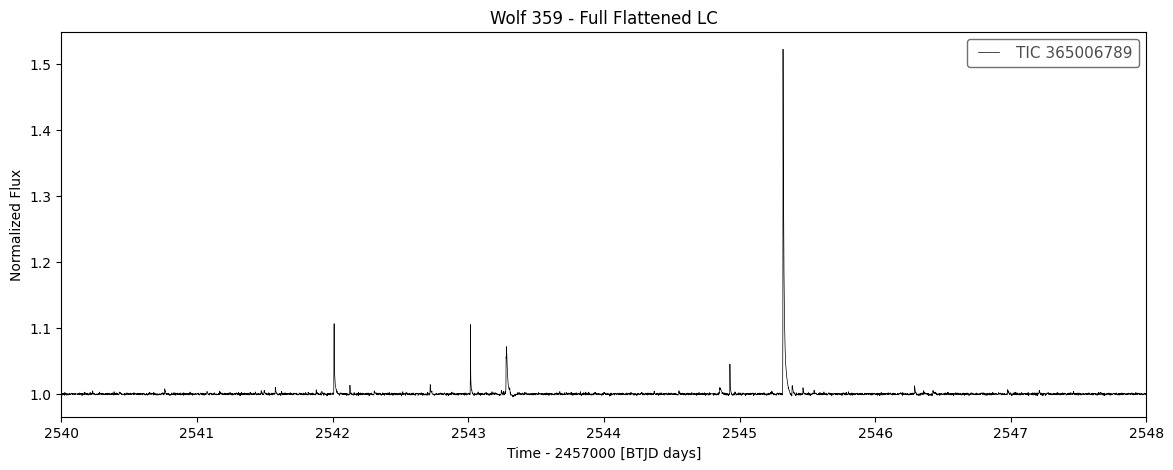

In [8]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

# get the data
search_result = lk.search_lightcurve("Wolf 359", mission="TESS", author="SPOC")
lc = search_result[2].download()
lc_norm = lc.normalize()
lc_flat = lc_norm.flatten()

# grab the raw arrays
time = lc_flat.time.value
flux = np.ma.filled(lc_flat.flux.value, fill_value=np.nanmedian(lc_flat.flux.value))

# manual windows for the 5 flares we want
windows = [
    (2545.2, 2545.5),    # Flare 1 (the monster)
    (2541.99, 2542.1),   # Flare 2
    (2542.99, 2543.1),   # Flare 3
    (2543.15, 2543.35),  # Flare 4
    (2544.8, 2545.1),    # Flare 5
]

print("Detected Peaks in Windows:")
for i, (t_start, t_end) in enumerate(windows):
    mask = (time >= t_start) & (time <= t_end)
    if any(mask):
        p_idx = np.argmax(flux[mask])
        p_time = time[mask][p_idx]
        p_flux = flux[mask][p_idx]
        print(f"Flare {i+1} — Time: {p_time:.4f} | Flux: {p_flux:.4f}")

# plot the whole thing to check
fig, ax = plt.subplots(figsize=(14, 5))
lc_flat.plot(ax=ax, color='black', lw=0.5)
ax.set_xlim(2540, 2548)
ax.set_title("Wolf 359 - Full Flattened LC")
plt.show()

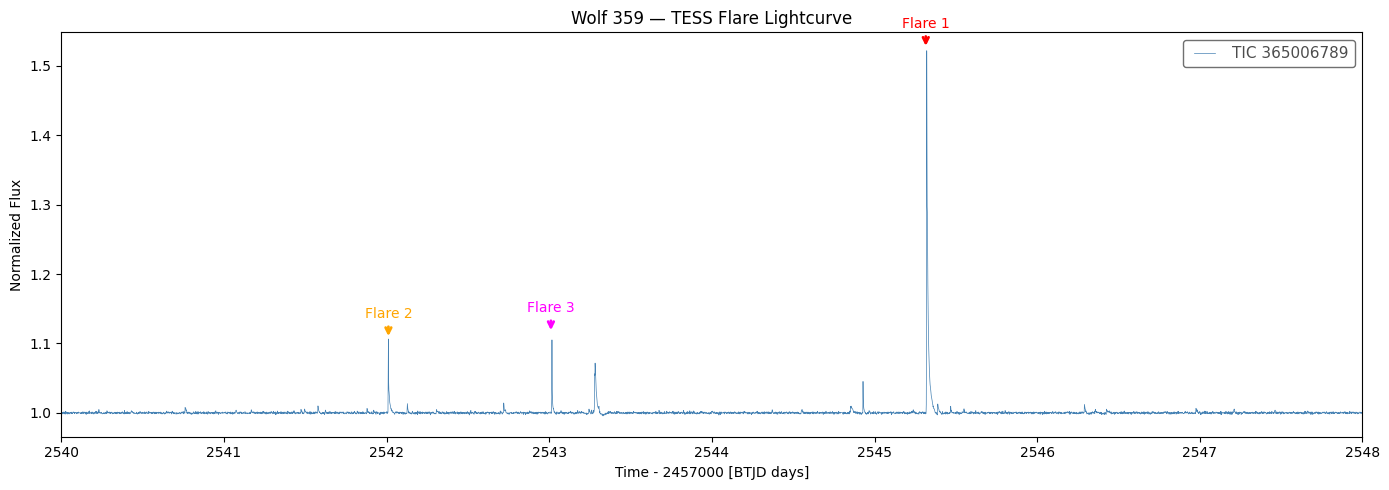

In [9]:
import lightkurve as lk
import matplotlib.pyplot as plt

search_result = lk.search_lightcurve("Wolf 359", mission="TESS", author="SPOC")
lc = search_result[2].download()

lc_norm = lc.normalize()
lc_flat = lc_norm.flatten()

fig, ax = plt.subplots(figsize=(14, 5))
lc_flat.plot(ax=ax, color='steelblue')


ax.set_xlim(2540, 2548)

# Three highest flares read from the plot
flares = [
    (2545.3150, 1.5245, 'Flare 1', 'red'),      
    (2542.0108, 1.1064, 'Flare 2', 'orange'),   
    (2543.01, 1.1150, 'Flare 3', 'magenta'),  
]
    
for (t, f, label, color) in flares:
    ax.annotate(label,
                xy=(t, f),
                xytext=(t, f + 0.03),
                color=color,
                fontsize=10,
                ha='center',
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

ax.set_title("Wolf 359 — TESS Flare Lightcurve")
plt.tight_layout()

plt.show()

Flare    Start           End             Amp%           
-------------------------------------------------------
Flare 1   2545.3139       2545.3861       50.32          %
Flare 2   2541.9969       2542.0497       9.79           %
Flare 3   2543.0081       2543.0373       10.28          %
Flare 4   2543.2567       2543.3304       6.75           %
Flare 5   2544.9180       2544.9527       4.45           %


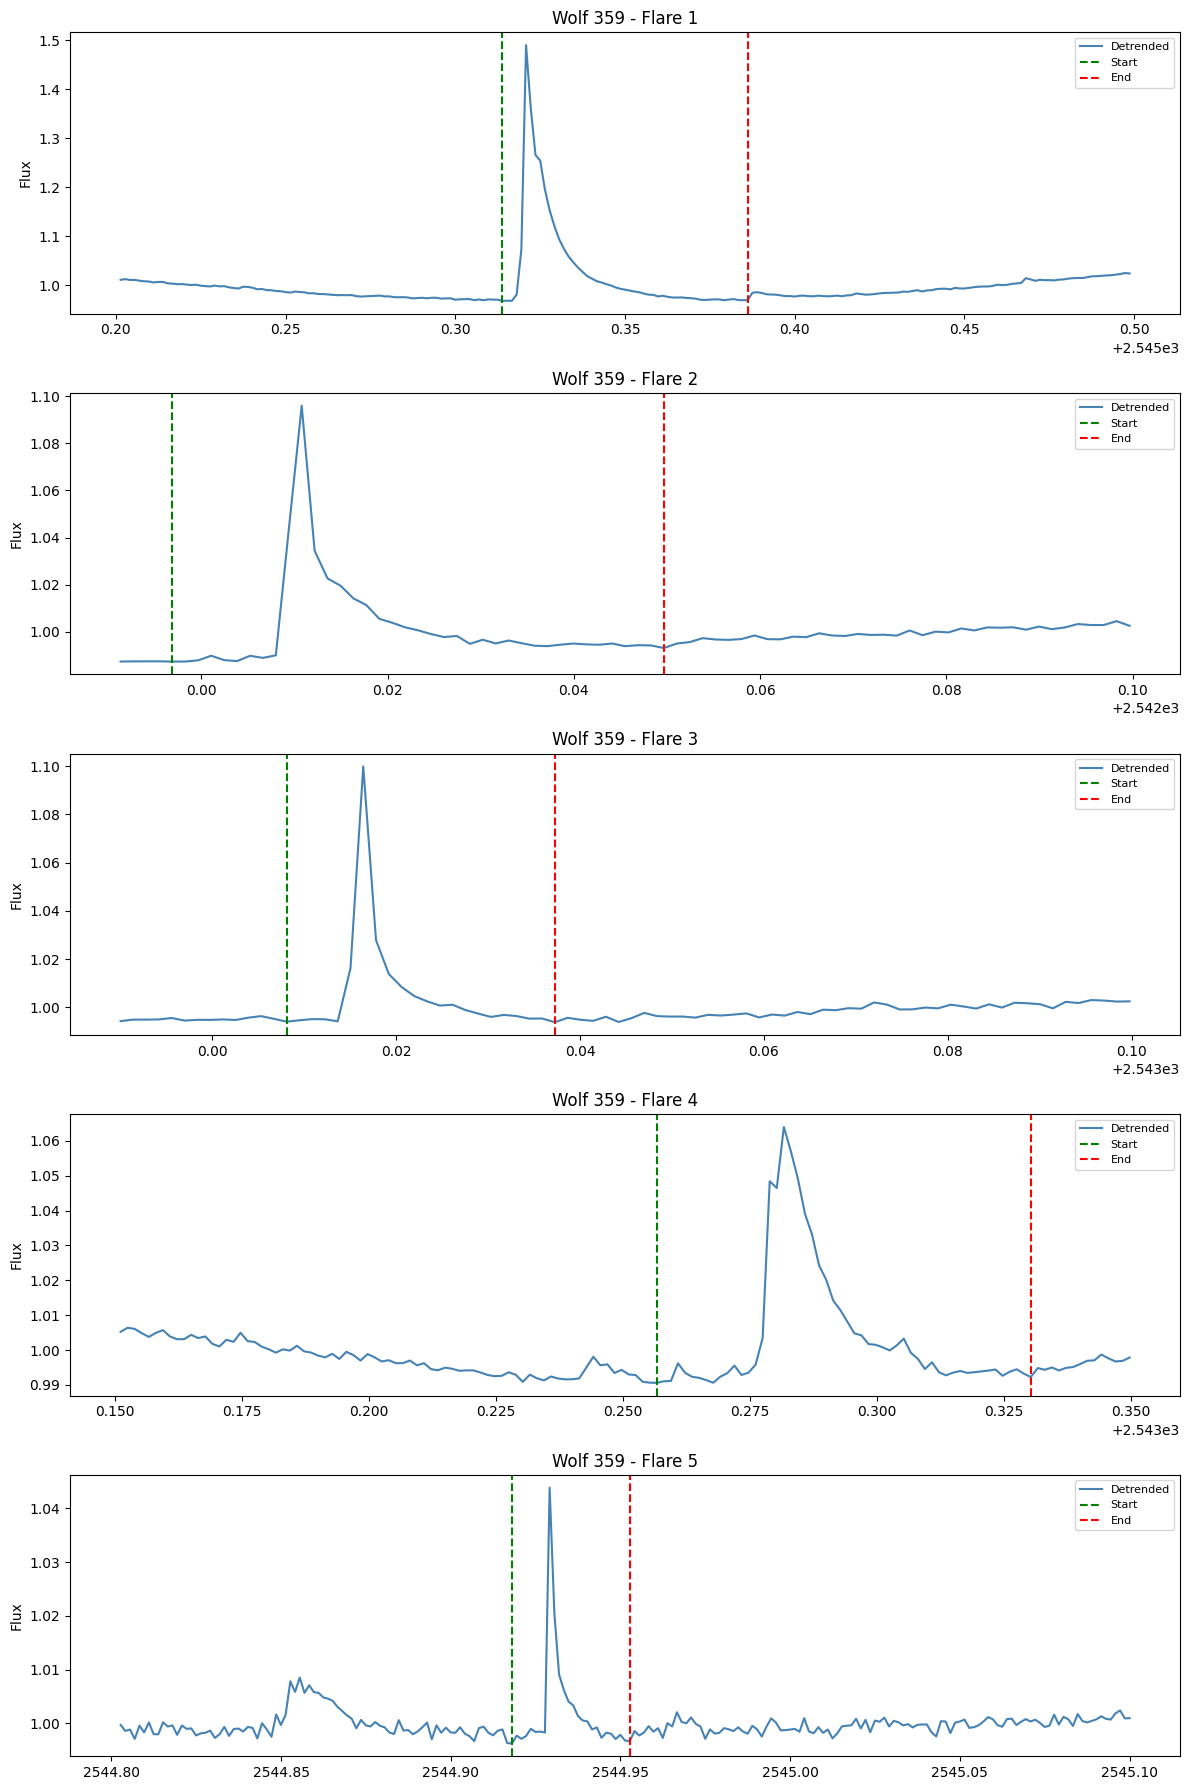

In [10]:
# table header
print(f"{'Flare':<8} {'Start':<15} {'End':<15} {'Amp%':<15}")
print("-" * 55)

# setup the 5 stacked plots
fig, axes = plt.subplots(5, 1, figsize=(12, 18))

for i, (t_start, t_end) in enumerate(windows):
    # zoom in on flare
    mask = (time >= t_start) & (time <= t_end)
    f_time, f_flux = time[mask], flux[mask]
    
    # fix any leftover slope in the window
    poly = np.polyfit(f_time, f_flux, deg=2)
    f_flux_d = f_flux - np.polyval(poly, f_time) + 1

    # stats
    p_idx = np.argmax(f_flux_d)
    p_flux = f_flux_d[p_idx]
    baseline = np.median(f_flux_d)
    
    # find start (min flux before peak)
    l_f, l_t = f_flux_d[:p_idx], f_time[:p_idx]
    f_start = l_t[np.argmin(l_f)] if len(l_f) > 0 else f_time[0]

    # find end (min flux after peak)
    r_f, r_t = f_flux_d[p_idx:], f_time[p_idx:]
    f_end = r_t[np.argmin(r_f)] if len(r_f) > 0 else f_time[-1]

    amp = p_flux - baseline

    print(f"Flare {i+1:<3} {f_start:<15.4f} {f_end:<15.4f} {amp*100:<15.2f}%")

    # plot on the correct subplot
    ax = axes[i]
    ax.plot(f_time, f_flux_d, color='steelblue', label='Detrended')
    ax.axvline(f_start, color='green', ls='--', label='Start')
    ax.axvline(f_end, color='red', ls='--', label='End')
    
    ax.set_title(f"Wolf 359 - Flare {i+1}")
    ax.set_ylabel("Flux")
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


Rotation period: 4.879 d days

Flare    Start           End             Amp%            FWHM(m)     
-----------------------------------------------------------------
Flare 1   1328.5028       1328.5375       2.46           % 6.00        
Flare 2   1333.8833       1333.9361       1.29           % 30.00       
Flare 3   1333.8833       1333.9361       1.24           % 26.00       
Flare 4   1334.1152       1334.1514       0.55           % 12.00       
Flare 5   1335.3416       1335.4097       3.71           % 10.00       


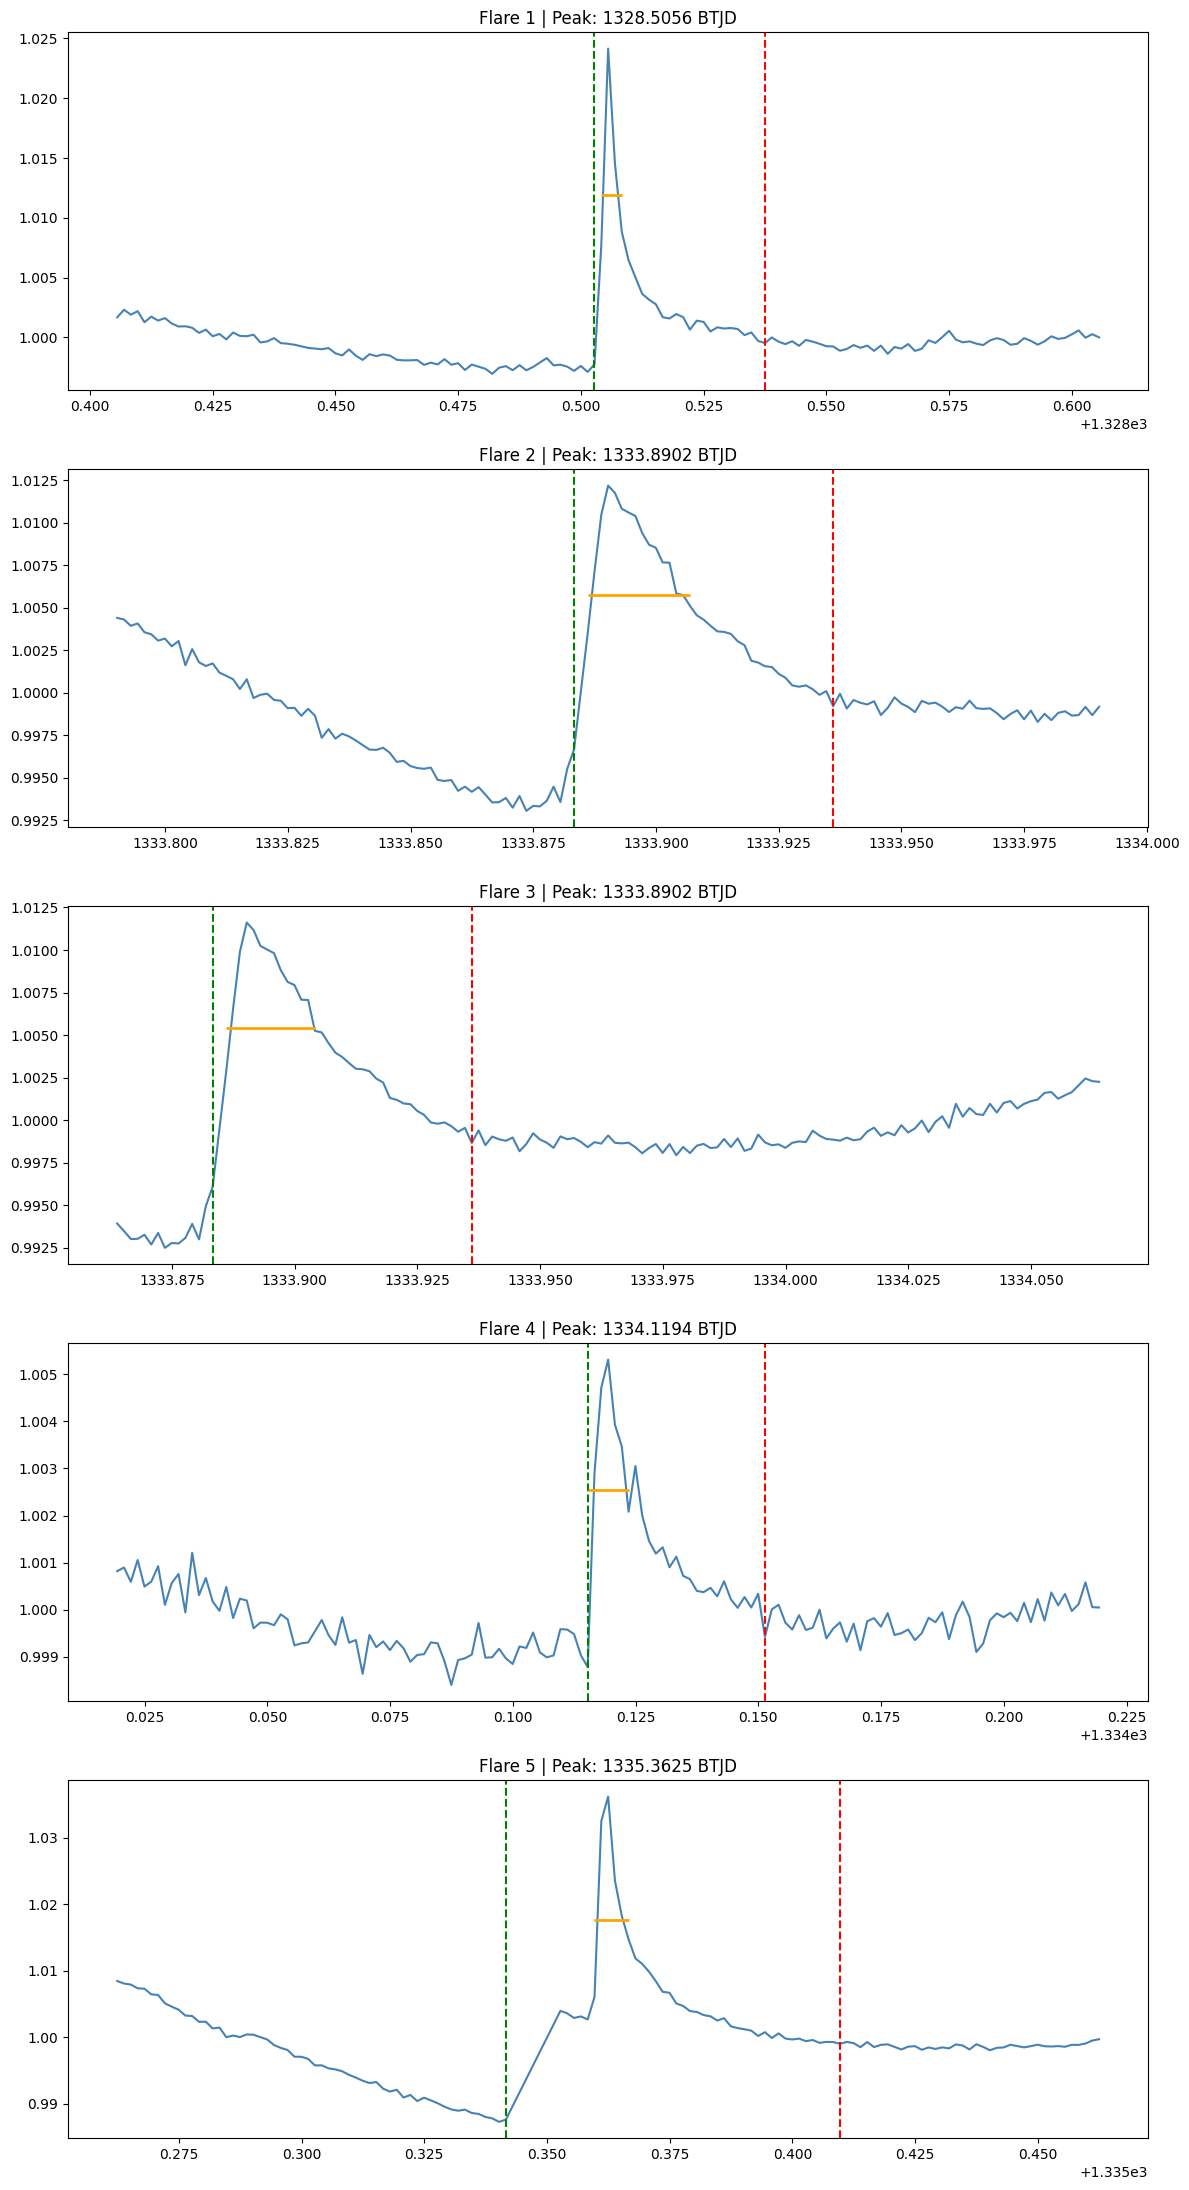

In [2]:
# THIS IS FOR STAR AU MIC

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import os

# make a folder for the txt files if it's not there
if not os.path.exists('flare_data'):
    os.makedirs('flare_data') 

# grab AU Mic data from TESS
search = lk.search_lightcurve("AU Mic", mission="TESS", author="SPOC", exptime=120)
lc_raw = search[0].download()
lc_norm = lc_raw.normalize()

# find how fast the star spins (rot period)
pg = lc_norm.to_periodogram(method='lombscargle', minimum_period=1.0, maximum_period=20.0)
rot_period = pg.period_at_max_power
print(f"\nRotation period: {rot_period:.3f} days")

# flatten lc to kill the star's rotation signal
cadence_days = np.nanmedian(np.diff(lc_norm.time.value))
window_cadences = int(rot_period.value / cadence_days)
if window_cadences % 2 == 0:
    window_cadences += 1  

lc_flat = lc_norm.flatten(window_length=window_cadences).remove_nans()
time = lc_flat.time.value
flux = np.ma.filled(lc_flat.flux.value, fill_value=np.nanmedian(lc_flat.flux.value))

# search for the biggest flares (3-sigma threshold)
global_median = np.median(flux)
global_std = np.std(flux)
threshold = global_median + 3 * global_std
peaks, _ = find_peaks(flux, height=threshold, distance=50)

# if we didn't find enough, lower the bar to 2-sigma
if len(peaks) < 5:
    threshold = global_median + 2 * global_std
    peaks, _ = find_peaks(flux, height=threshold, distance=50)

# pick the 5 strongest peaks and sort them by time
top5_idx = peaks[np.argsort(flux[peaks])[-5:]]
top5_idx = np.sort(top5_idx)

# 0.1 day buffer around each flare for plotting
padding = 0.1
windows_amic = [(time[idx] - padding, time[idx] + padding) for idx in top5_idx]

print(f"\n{'Flare':<8} {'Start':<15} {'End':<15} {'Amp%':<15} {'FWHM(m)':<12}")
print("-" * 65)

# setup 5 stacked plots
fig, axes = plt.subplots(5, 1, figsize=(12, 22))

for i, (t_start, t_end) in enumerate(windows_amic):
    # zoom in on just the flare
    mask = (time >= t_start) & (time <= t_end)
    f_time, f_flux = time[mask], flux[mask]

    # detrend the local window to make it flat at 1.0
    poly_fit = np.polyfit(f_time, f_flux, deg=2)
    f_flux_d = f_flux - np.polyval(poly_fit, f_time) + 1  

    # get peak and baseline info
    p_idx = np.argmax(f_flux_d)
    p_flux, p_time = f_flux_d[p_idx], f_time[p_idx]
    med = np.median(f_flux_d)
    amp = p_flux - med

    # find where flare starts and ends (crosses median)
    l_f, l_t = f_flux_d[:p_idx], f_time[:p_idx]
    low_l = np.where(l_f <= med)[0]
    f_start = l_t[low_l[-1]] if len(low_l) > 0 else f_time[0]

    r_f, r_t = f_flux_d[p_idx:], f_time[p_idx:]
    low_r = np.where(r_f <= med)[0]
    f_end = r_t[low_r[0]] if len(low_r) > 0 else f_time[-1]

    # calculate FWHM (width at half-amplitude)
    h_max = med + amp / 2
    fwhm_l = l_t[np.where(l_f <= h_max)[0][-1]] if len(np.where(l_f <= h_max)[0]) > 0 else f_time[0]
    fwhm_r = r_t[np.where(r_f <= h_max)[0][0]] if len(np.where(r_f <= h_max)[0]) > 0 else f_time[-1]
    fwhm_m = (fwhm_r - fwhm_l) * 24 * 60  

    #  stats into individual txt files
    fname = os.path.join('flare_data', f"flare_{i+1}_stats.txt")
    with open(fname, "w") as f:
        f.write(f"Flare {i+1}\nStart: {f_start:.4f}\nEnd: {f_end:.4f}\nAmp: {amp*100:.2f}%\nFWHM: {fwhm_m:.2f}m")

    # print row to console
    print(f"Flare {i+1:<3} {f_start:<15.4f} {f_end:<15.4f} {amp*100:<15.2f}% {fwhm_m:<12.2f}")

    # plot flux, start/end lines, and FWHM bar
    ax = axes[i]
    ax.plot(f_time, f_flux_d, color='steelblue')
    ax.axvline(f_start, color='green', ls='--')
    ax.axvline(f_end, color='red', ls='--')
    ax.hlines(h_max, fwhm_l, fwhm_r, color='orange', lw=2)
    ax.set_title(f"Flare {i+1} | Peak: {p_time:.4f} BTJD")

# clean up and show the 5-panel plot
plt.tight_layout()
plt.show()


Rotation period: 4.879 d days

Flare    Start           End             Amp%            FWHM(m)     
-----------------------------------------------------------------
Flare 1   1328.5028       1328.5375       2.41           % 6.00        
Flare 2   1333.8805       1333.9361       1.71           % 30.00       
Flare 3   1335.1097       1335.1819       3.12           % 30.00       
Flare 4   1335.3416       1335.4138       3.46           % 8.00        
Flare 5   1350.1440       1350.1746       1.44           % 8.00        


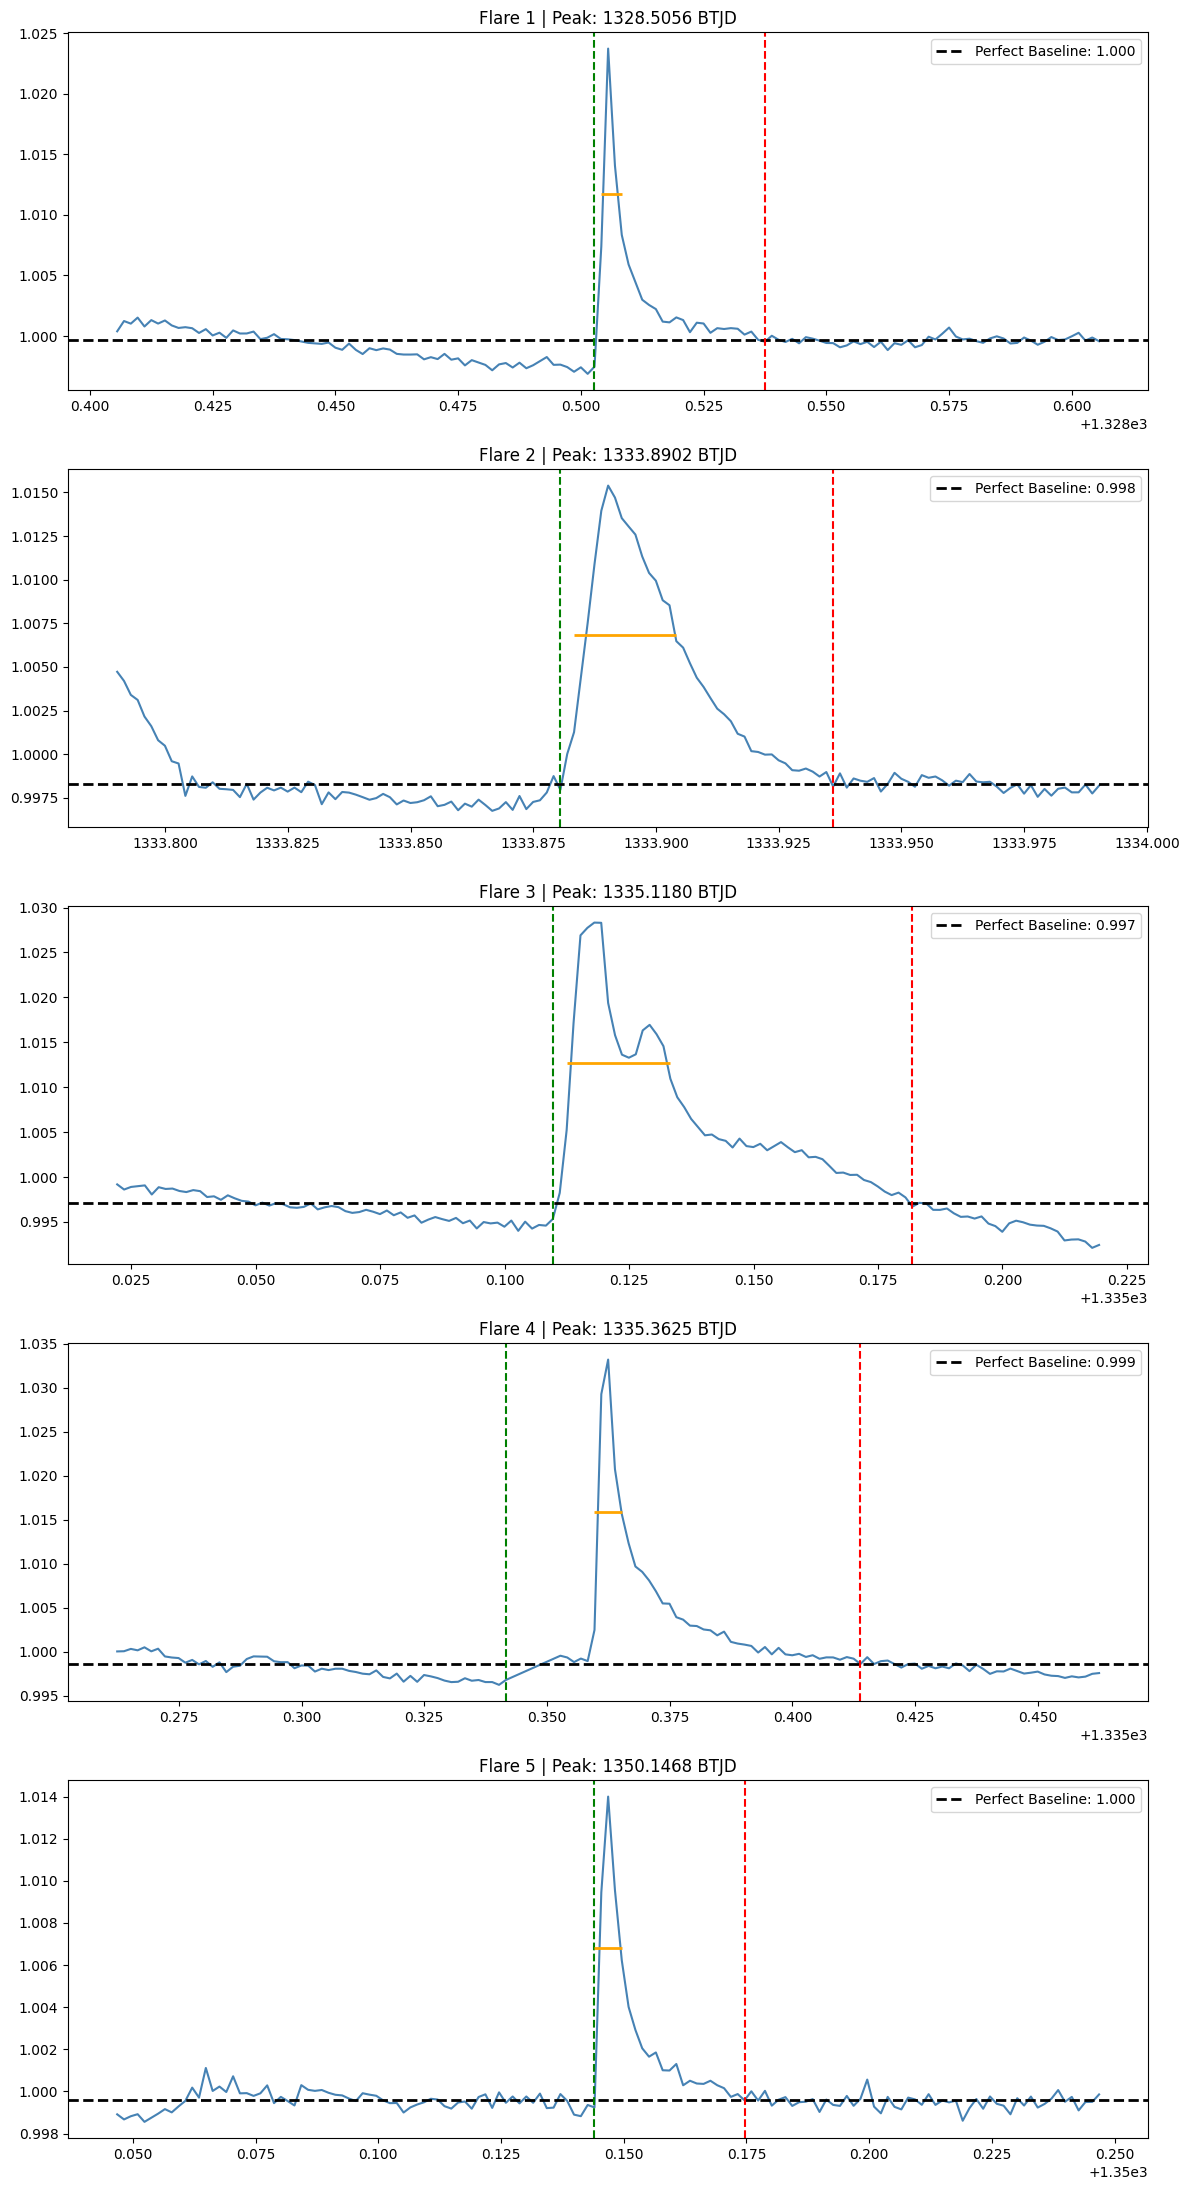

In [ ]:
# THIS IS FOR STAR AU MIC
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import os

# FOLDER
if not os.path.exists('flare_data'):
    os.makedirs('flare_data') 

# DATA GRAB
search = lk.search_lightcurve("AU Mic", mission="TESS", author="SPOC", exptime=120)
lc_raw = search[0].download()
lc_norm = lc_raw.normalize().remove_nans()

# PERIOD CALCULATION
pg = lc_norm.to_periodogram(method='lombscargle', minimum_period=1.0, maximum_period=20.0)
rot_period = pg.period_at_max_power
print(f"\nRotation period: {rot_period:.3f} days")

# PROPER DETREND (Flattening for Straight Lines)
# We use a window that is exactly 1/4 of the rotation period.
# This is tight enough to kill the dips but wide enough to keep flares intact.
cadence_days = np.nanmedian(np.diff(lc_norm.time.value))
window_length = int((rot_period.value / 4) / cadence_days)
if window_length % 2 == 0: window_length += 1

# Flatten the lightcurve - this is the "Global Straightener"
lc_flat = lc_norm.flatten(window_length=window_length)

# PEAK FINDING
time = lc_flat.time.value
# Using .value to ensure we have a plain array for scipy
flux = np.array(lc_flat.flux.value)

global_median = np.nanmedian(flux)
global_std = np.nanstd(flux)
threshold = global_median + 3 * global_std
peaks, _ = find_peaks(flux, height=threshold, distance=50)

if len(peaks) < 5:
    threshold = global_median + 2 * global_std
    peaks, _ = find_peaks(flux, height=threshold, distance=50)

top5_idx = peaks[np.argsort(flux[peaks])[-5:]]
top5_idx = np.sort(top5_idx)

padding = 0.1
windows_amic = [(time[idx] - padding, time[idx] + padding) for idx in top5_idx]

print(f"\n{'Flare':<8} {'Start':<15} {'End':<15} {'Amp%':<15} {'FWHM(m)':<12}")
print("-" * 65)

# ORIGINAL 5-STACKED PLOTS
fig, axes = plt.subplots(5, 1, figsize=(12, 22))

for i, (t_start, t_end) in enumerate(windows_amic):
    mask = (time >= t_start) & (time <= t_end)
    f_time, f_flux = time[mask], flux[mask]

    # LOCAL STRAIGHTENER 
    # This takes any remaining "U" shape in the zoomed window and flattens it
    # by subtracting a simple linear trend.
    coeffs = np.polyfit(f_time, f_flux, 1)
    f_flux_d = f_flux - np.polyval(coeffs, f_time) + 1

    p_idx = np.argmax(f_flux_d)
    p_flux, p_time = f_flux_d[p_idx], f_time[p_idx]
    
    # CALCULATE MEDIAN (The Target Straight Line)
    med = np.nanmedian(f_flux_d)
    amp = p_flux - med

    # BOUNDARY LOGIC
    l_f, l_t = f_flux_d[:p_idx], f_time[:p_idx]
    low_l = np.where(l_f <= med)[0]
    f_start = l_t[low_l[-1]] if len(low_l) > 0 else f_time[0]

    r_f, r_t = f_flux_d[p_idx:], f_time[p_idx:]
    low_r = np.where(r_f <= med)[0]
    f_end = r_t[low_r[0]] if len(low_r) > 0 else f_time[-1]

    # ORIGINAL FWHM LOGIC
    h_max = med + amp / 2
    fwhm_l = l_t[np.where(l_f <= h_max)[0][-1]] if len(np.where(l_f <= h_max)[0]) > 0 else f_time[0]
    fwhm_r = r_t[np.where(r_f <= h_max)[0][0]] if len(np.where(r_f <= h_max)[0]) > 0 else f_time[-1]
    fwhm_m = (fwhm_r - fwhm_l) * 24 * 60  

    # ORIGINAL FILE SAVING
    fname = os.path.join('flare_data', f"flare_{i+1}_stats.txt")
    with open(fname, "w") as f:
        f.write(f"Flare {i+1}\nStart: {f_start:.4f}\nEnd: {f_end:.4f}\nAmp: {amp*100:.2f}%\nFWHM: {fwhm_m:.2f}m")

    print(f"Flare {i+1:<3} {f_start:<15.4f} {f_end:<15.4f} {amp*100:<15.2f}% {fwhm_m:<12.2f}")

    # 7. ORIGINAL PLOTTING + THE STRAIGHT MEDIAN LINE
    ax = axes[i]
    ax.plot(f_time, f_flux_d, color='steelblue')
    
    # Visual Straight Line Baseline
    ax.axhline(med, color='black', linestyle='--', linewidth=2, label=f'Perfect Baseline: {med:.3f}')
    
    ax.axvline(f_start, color='green', ls='--')
    ax.axvline(f_end, color='red', ls='--')
    ax.hlines(h_max, fwhm_l, fwhm_r, color='orange', lw=2)
    ax.set_title(f"Flare {i+1} | Peak: {p_time:.4f} BTJD")
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

#NEW STUFF:
# 1. savgol filter (learn)
# 2. local straightener (polyfit and polyval)